In [1]:
import os, requests, zipfile, cv2, numpy as np
from pycocotools.coco import COCO
from tqdm import tqdm
from google.colab import drive

drive.mount('/content/drive')
BASE = "/content/drive/MyDrive/coco20k"
IMG_DIR = f"{BASE}/images"
MASK_DIR = f"{BASE}/masks"
TRAIN_IMG = f"{BASE}/train/images"
TRAIN_MASK = f"{BASE}/train/masks"
VAL_IMG = f"{BASE}/val/images"
VAL_MASK = f"{BASE}/val/masks"

for d in [IMG_DIR, MASK_DIR, TRAIN_IMG, TRAIN_MASK, VAL_IMG, VAL_MASK]:
    os.makedirs(d, exist_ok=True)

ANN_ZIP = "/content/ann2017.zip"
if not os.path.exists(ANN_ZIP):
    url = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"
    r = requests.get(url)
    open(ANN_ZIP, "wb").write(r.content)

with zipfile.ZipFile(ANN_ZIP, "r") as z:
    z.extractall("/content/coco_ann")

ANN_JSON = "/content/coco_ann/annotations/instances_train2017.json"
coco = COCO(ANN_JSON)

all_ids = coco.getImgIds()
np.random.shuffle(all_ids)
img_ids = all_ids[:20000]

def create_mask(img_id):
    anns = coco.loadAnns(coco.getAnnIds(imgIds=img_id))
    info = coco.loadImgs(img_id)[0]
    h, w = info["height"], info["width"]
    m = np.zeros((h, w), dtype=np.uint8)
    for a in anns:
        m = np.maximum(m, coco.annToMask(a))
    return info["file_name"], m

for img_id in tqdm(img_ids):
    info = coco.loadImgs(img_id)[0]
    url = info["coco_url"]
    img_name = info["file_name"]
    img_path = os.path.join(IMG_DIR, img_name)

    try:
        data = requests.get(url).content
        open(img_path, "wb").write(data)
        name, mask = create_mask(img_id)
        cv2.imwrite(os.path.join(MASK_DIR, name.replace(".jpg", ".png")), mask * 255)
    except:
        pass

files = sorted(os.listdir(IMG_DIR))
split = int(0.8 * len(files))

for f in files[:split]:
    os.rename(f"{IMG_DIR}/{f}", f"{TRAIN_IMG}/{f}")
    os.rename(f"{MASK_DIR}/{f.replace('.jpg','.png')}", f"{TRAIN_MASK}/{f.replace('.jpg','.png')}")

for f in files[split:]:
    os.rename(f"{IMG_DIR}/{f}", f"{VAL_IMG}/{f}")
    os.rename(f"{MASK_DIR}/{f.replace('.jpg','.png')}", f"{VAL_MASK}/{f.replace('.jpg','.png')}")

print("Dataset Ready!")
print("Train Images:", len(os.listdir(TRAIN_IMG)))
print("Train Masks:", len(os.listdir(TRAIN_MASK)))
print("Val Images:", len(os.listdir(VAL_IMG)))
print("Val Masks:", len(os.listdir(VAL_MASK)))


Mounted at /content/drive
loading annotations into memory...
Done (t=17.29s)
creating index...
index created!


100%|██████████| 20000/20000 [1:13:47<00:00,  4.52it/s]


Dataset Ready!
Train Images: 29256
Train Masks: 29256
Val Images: 7334
Val Masks: 7334


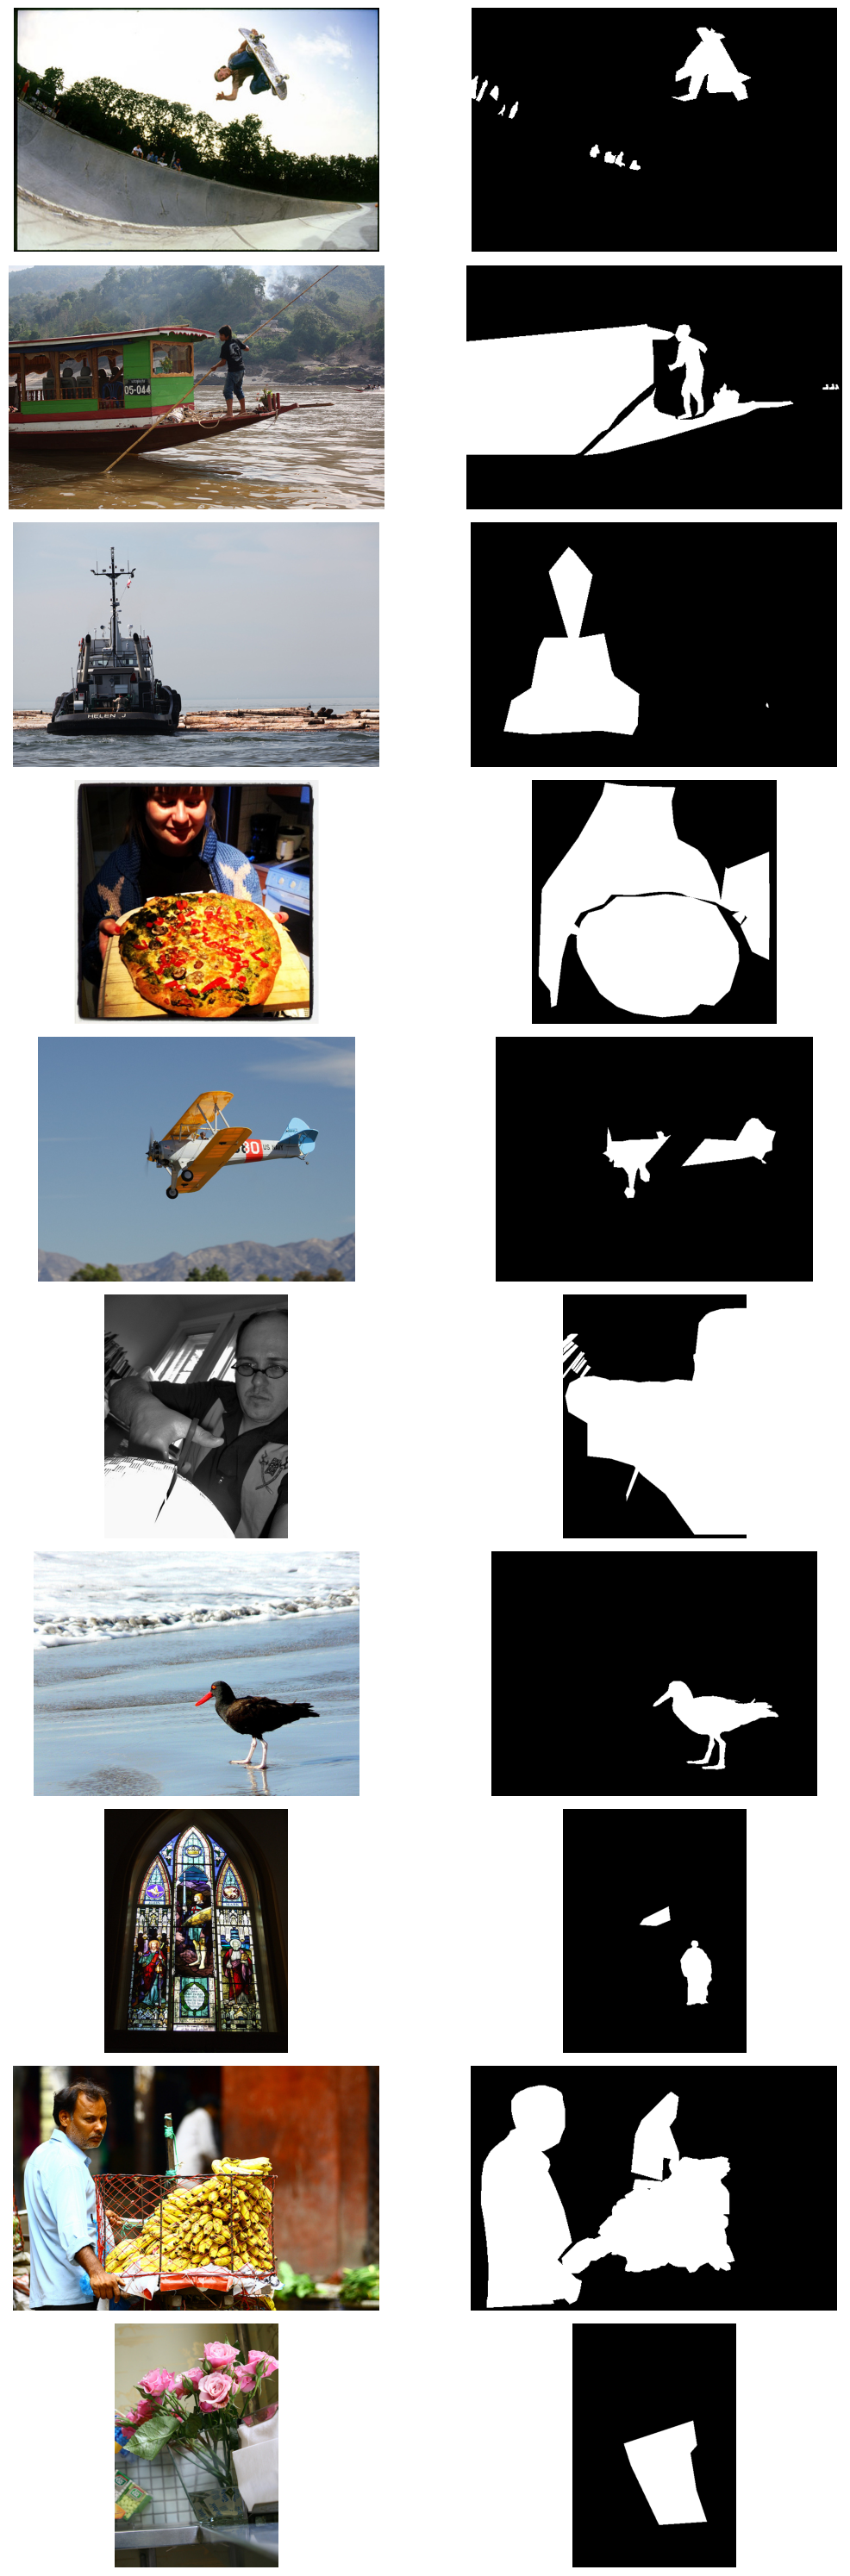

In [3]:
import os
import cv2
import random
import matplotlib.pyplot as plt

TRAIN_IMG = "/content/drive/MyDrive/coco20k/train/images"
TRAIN_MASK = "/content/drive/MyDrive/coco20k/train/masks"

files = sorted(os.listdir(TRAIN_IMG))
sample = random.sample(files, 10)

plt.figure(figsize=(12, 30))

idx = 1
for f in sample:
    img = cv2.imread(os.path.join(TRAIN_IMG, f))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(os.path.join(TRAIN_MASK, f.replace(".jpg", ".png")), cv2.IMREAD_GRAYSCALE)

    plt.subplot(10, 2, idx); idx += 1
    plt.imshow(img); plt.axis("off")

    plt.subplot(10, 2, idx); idx += 1
    plt.imshow(mask, cmap="gray"); plt.axis("off")

plt.tight_layout()
plt.show()
